In [4]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame = True)
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
df = iris.frame.copy()
df.head

<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

In [10]:
df.target.unique()

array([0, 1, 2])

In [11]:
df.columns = ['sepal_length','sepal_width','petal_length','petal_width','target']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [14]:
df = df.drop(columns=['target'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

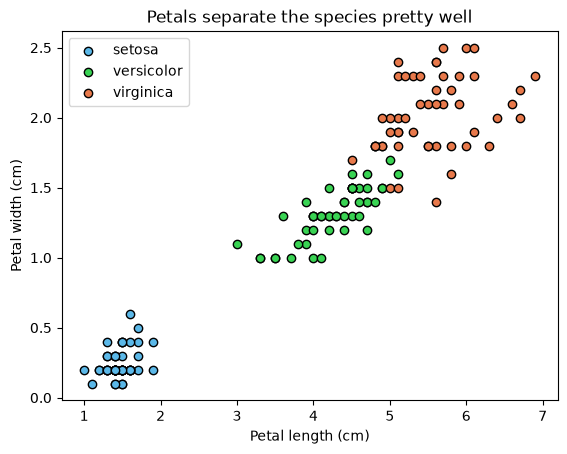

In [16]:
import matplotlib.pyplot as plt

colors = {'setosa': '#5BB8E8', 'versicolor': '#39D353', 'virginica': '#E8794B'}
for name, group in df.groupby('species'):
    plt.scatter(group.petal_length, group.petal_width,
                color=colors[name], edgecolor='k', label=name)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Petals separate the species pretty well")
plt.legend()
plt.show()

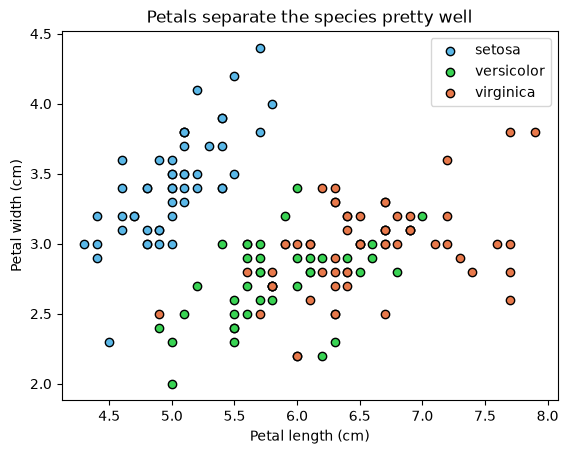

In [17]:
import matplotlib.pyplot as plt

colors = {'setosa': '#5BB8E8', 'versicolor': '#39D353', 'virginica': '#E8794B'}
for name, group in df.groupby('species'):
    plt.scatter(group.sepal_length, group.sepal_width,
                color=colors[name], edgecolor='k', label=name)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Petals separate the species pretty well")
plt.legend()
plt.show()

In [18]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
y = df.species

print("X shape:", X.shape)
print("Classes:", list(y.unique()))

X shape: (150, 4)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 120
Testing rows:  30


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("Learned classes:", model.classes_)

Learned classes: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]


In [22]:
import pandas as pd
y_pred = model.predict(X_test)

compare = pd.DataFrame({'actual':y_test.values,'predicted':y_pred})
compare.head(10)

,actual,predicted
0,virginica,virginica
1,virginica,virginica
2,virginica,versicolor
3,versicolor,versicolor
4,virginica,virginica
5,setosa,setosa
6,versicolor,versicolor
7,setosa,setosa
8,setosa,setosa
9,versicolor,versicolor


In [23]:
sample = X_test.iloc[[0]]
probs = model.predict_proba(sample)[0]
for species, p in zip(model.classes_, probs):
    print(f"{species:12s} -> {p:.2f}")
print("\nPredicted:", model.predict(sample)[0])

setosa       -> 0.00
versicolor   -> 0.09
virginica    -> 0.91

Predicted: virginica


In [24]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy on the test set: {accuracy:.2f}")

Accuracy on the test set: 0.93


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print(cm)

[[ 9  0  0]
 [ 0 10  0]
 [ 0  2  9]]


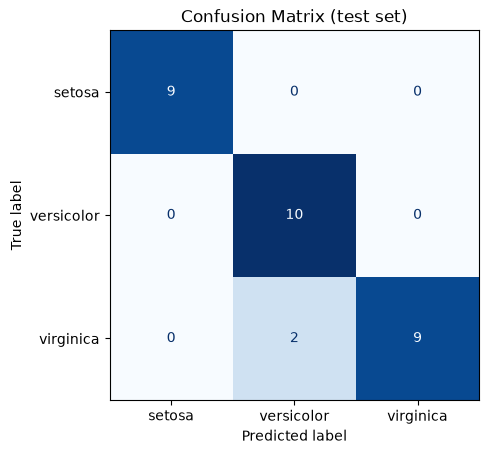

In [26]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (test set)')
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.94      0.93      0.93        30



In [29]:
new_flower = pd.DataFrame([{
    'sepal_length': 5.1, 'sepal_width': 3.5,
    'petal_length': 1.4, 'petal_width': 0.2
}])
print("Predicted species:", model.predict(new_flower)[0])

Predicted species: setosa
